In [2]:
# import networkx
import lovelyplots
import networkx as nx
import numpy as np
import rustworkx as rx
import scienceplots
from rustworkx.visualization import graphviz_draw, mpl_draw
from scipy.optimize import minimize

from corral_crowding.allocation_optimizer import GateFidelityOptimizer
from corral_crowding.detuning_fit import compute_infidelity_parameters, decay_fit
from corral_crowding.module_graph import QuantumModuleGraph
import matplotlib.pyplot as plt

In [9]:
[3.66966045, 5.13640275]
[3.33, 4.04]

[3.33, 4.04]

In [10]:
1 - 6.216490e-03

0.99378351

In [11]:
1 - 1.175726e-03

0.998824274

100%|██████████| 128/128 [00:02<00:00, 43.49it/s]


Optimization terminated successfully.
Lifetime loss not considered.
Qubit Frequencies: [3.50807338 5.7        3.3       ] GHz
SNAIL Frequency: 4.667213286673634 GHz
Gate Infidelities:
  Gate ('Q0', 'Q1'): 2.191927 GHz → fidelity (no lifetime loss): 9.999901e-01, fidelity (with lifetime loss): 9.999901e-01
  Gate ('Q0', 'Q2'): 0.208073 GHz → fidelity (no lifetime loss): 1.000000e+00, fidelity (with lifetime loss): 1.000000e+00
  Gate ('Q1', 'Q2'): 2.400000 GHz → fidelity (no lifetime loss): 9.999914e-01, fidelity (with lifetime loss): 9.999914e-01

Average Gate fidelity (no lifetime loss): 1.0
Average Gate fidelity (with lifetime loss): 1.0


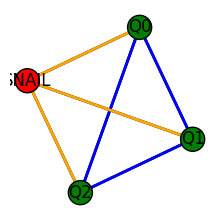

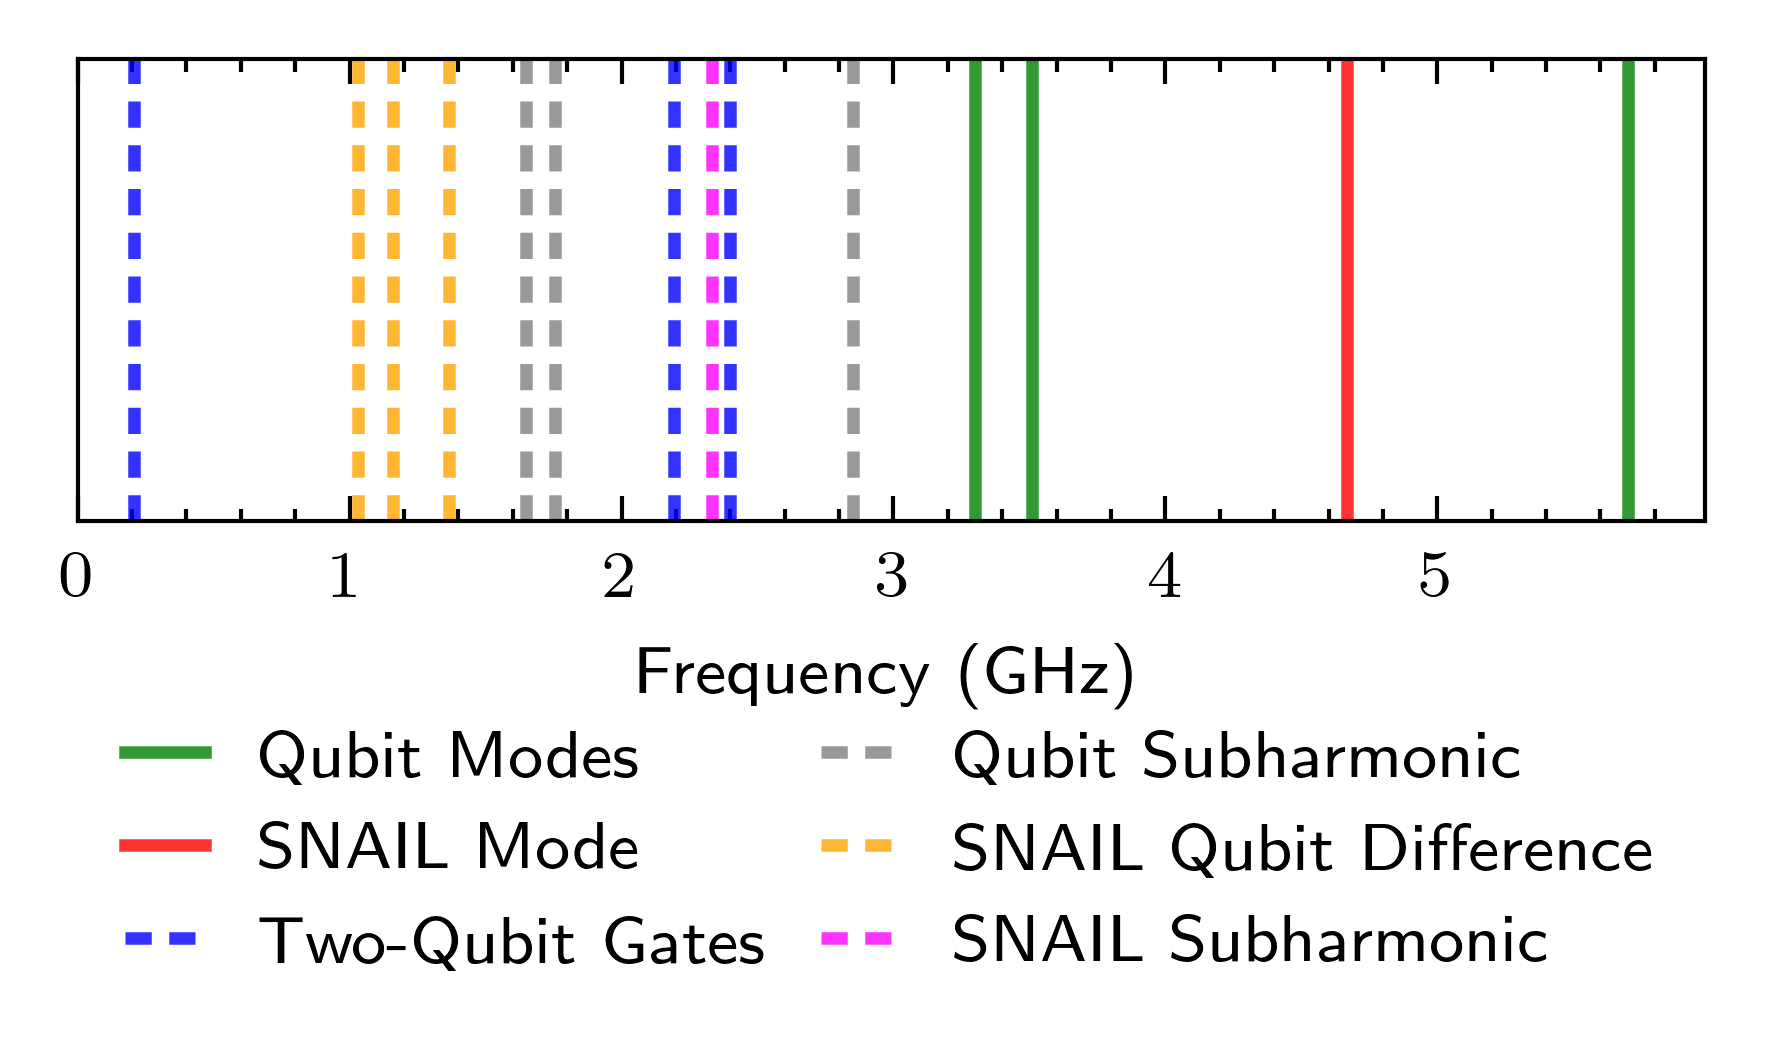

In [3]:
# baseline from Israa+Gaurav initial designs
module = QuantumModuleGraph(num_qubits=3)
optimizer = GateFidelityOptimizer(
    module,
    min_bare_space_ghz=0.12,
    lambdaq=0.1,
    eta=.4,
    g3=60e6,
    qubit_bounds=(3.3, 5.7),
    snail_bounds=(4.2, 4.7),
    use_lifetime=False,
)
# optimizer.best_frequencies = [3.33, 5.67, 4.04, 5.30, 4.69]
# optimizer.best_frequencies = [3.33, 5.70, 5.13640275, 5.3, 4.69]
# optimizer.best_frequencies = [
#     5.4899135,
#     5.68991503,
#     5.16990618,
#     3.32081487,
#     4.320820630283993,
# ]

optimizer.optimize_frequencies()
optimizer.report_results()

In [12]:
# baseline from Israa+Gaurav initial designs
module = QuantumModuleGraph(num_qubits=4)
optimizer = GateFidelityOptimizer(
    module,
    min_bare_space_ghz=0.12,
    lambdaq=0.08,
    eta=1.8,
    g3=60e6,
    qubit_bounds=(3.3, 5.7),
    snail_bounds=(4.2, 4.7),
    use_lifetime=True,
)
# optimizer.best_frequencies = [3.33, 5.67, 4.04, 5.30, 4.69]
# optimizer.best_frequencies = [3.33, 5.70, 5.13640275, 5.3, 4.69]
# optimizer.best_frequencies = [
#     5.4899135,
#     5.68991503,
#     5.16990618,
#     3.32081487,
#     4.320820630283993,
# ]
optimizer.report_results()

No optimized frequencies available.


100%|██████████| 128/128 [00:10<00:00, 12.20it/s]

Optimization terminated successfully.
Qubit Frequencies: [3.8814631  5.64214108 4.08146681 5.32213268] GHz
SNAIL Frequency: 4.696488720199293 GHz
Gate Infidelities:
  Gate ('Q0', 'Q1'): 1.760678 GHz → fidelity (no lifetime loss): 9.914007e-01, fidelity (with lifetime loss): 9.886546e-01
  Gate ('Q0', 'Q2'): 0.200004 GHz → fidelity (no lifetime loss): 9.876819e-01, fidelity (with lifetime loss): 9.864773e-01
  Gate ('Q0', 'Q3'): 1.440670 GHz → fidelity (no lifetime loss): 9.934143e-01, fidelity (with lifetime loss): 9.912315e-01
  Gate ('Q1', 'Q2'): 1.560674 GHz → fidelity (no lifetime loss): 9.942293e-01, fidelity (with lifetime loss): 9.918612e-01
  Gate ('Q1', 'Q3'): 0.320008 GHz → fidelity (no lifetime loss): 9.776857e-01, fidelity (with lifetime loss): 9.764397e-01
  Gate ('Q2', 'Q3'): 1.240666 GHz → fidelity (no lifetime loss): 9.823733e-01, fidelity (with lifetime loss): 9.804618e-01

Average Gate fidelity (no lifetime loss): 0.9892039486035286
Average Gate fidelity (with lifetim

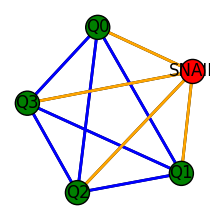

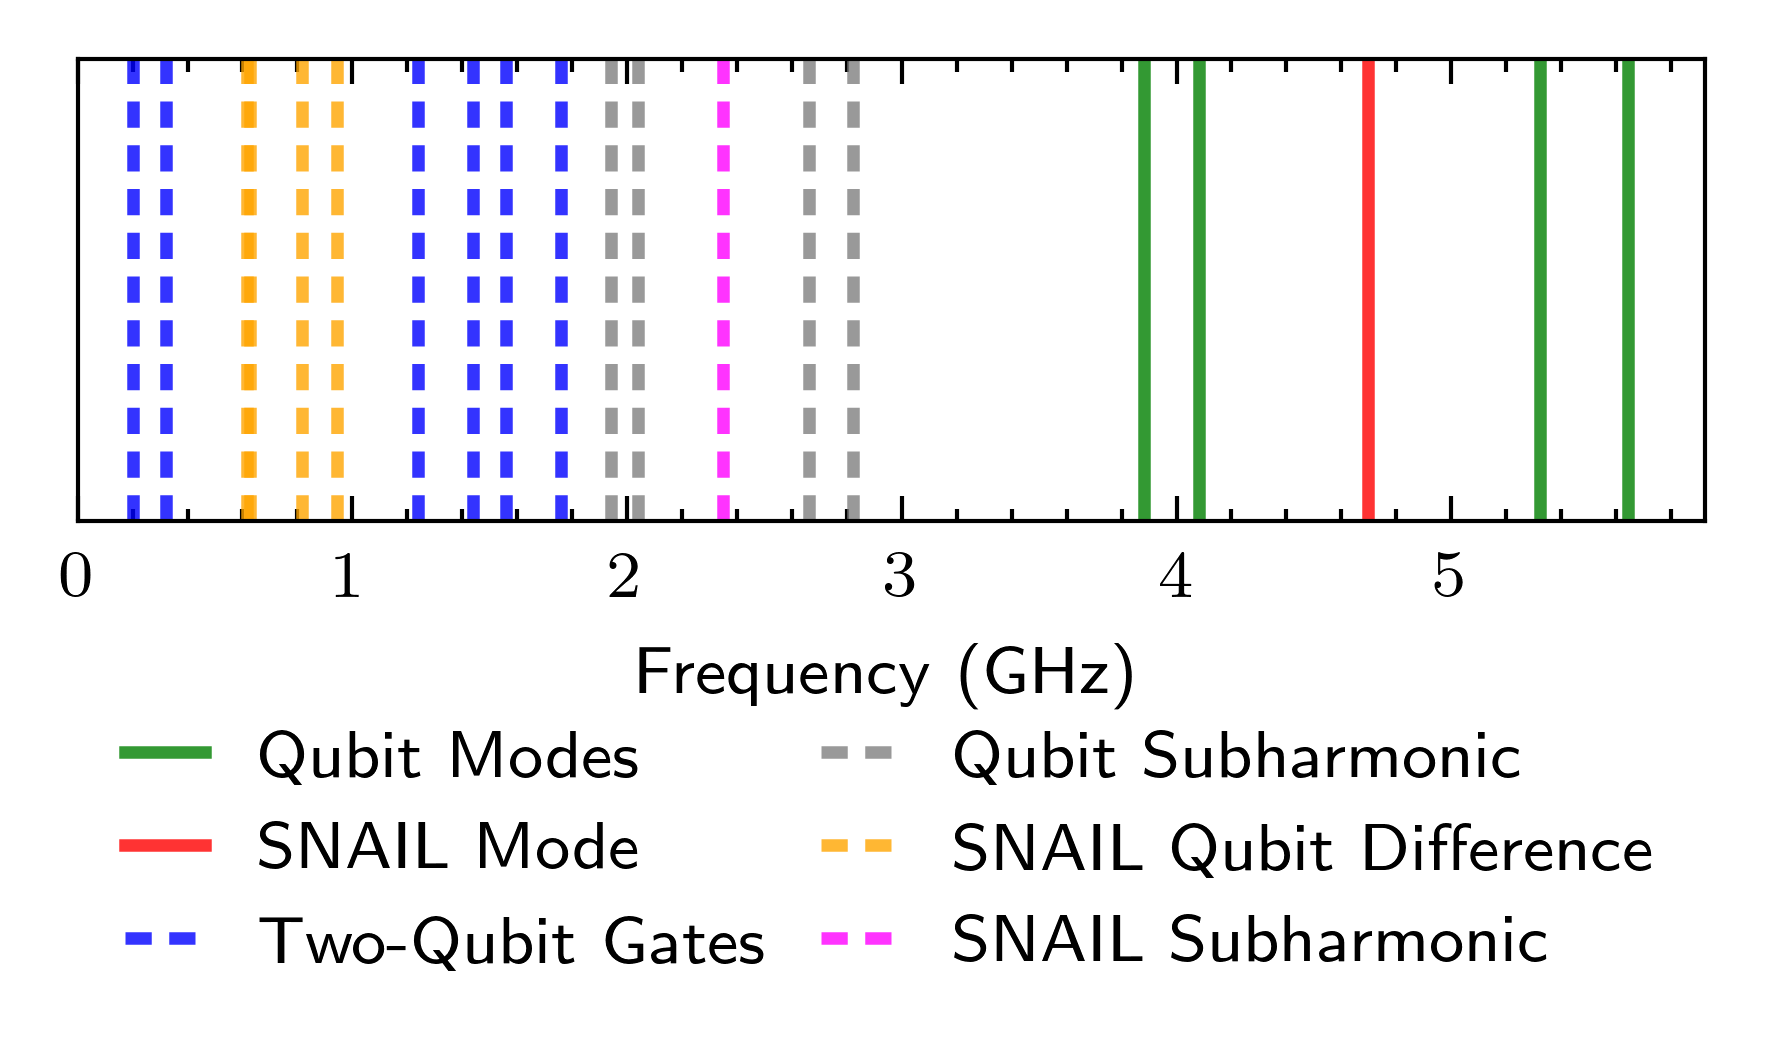

In [49]:
module = QuantumModuleGraph(num_qubits=4)
optimizer = GateFidelityOptimizer(
    module,
    min_bare_space_ghz=0.2,
    lambdaq=0.08,
    eta=1.8,
    g3=60e6,
    qubit_bounds=(3.3, 5.7),
    snail_bounds=(4.2, 4.7),
    use_lifetime=True,
    drop_k=0,
)
opt_frequencies, opt_cost = optimizer.optimize_frequencies()
optimizer.report_results()

Qubit Frequencies: [3.30703304 3.70103918 5.45757537 5.7       ] GHz
SNAIL Frequency: 4.505993115261459 GHz
Gate Infidelities:
  Gate ('Q0', 'Q1'): 0.394006 GHz → fidelity (no lifetime loss): 9.928639e-01, fidelity (with lifetime loss): 9.915129e-01
  Gate ('Q0', 'Q2'): 2.150542 GHz → fidelity (no lifetime loss): 9.959661e-01, fidelity (with lifetime loss): 9.914052e-01
  Gate ('Q0', 'Q3'): 2.392967 GHz → fidelity (no lifetime loss): 9.962491e-01, fidelity (with lifetime loss): 9.919063e-01
  Gate ('Q1', 'Q2'): 1.756536 GHz → fidelity (no lifetime loss): 9.546612e-01, fidelity (with lifetime loss): 9.518049e-01
  Gate ('Q1', 'Q3'): 1.998961 GHz → fidelity (no lifetime loss): 9.890374e-01, fidelity (with lifetime loss): 9.852760e-01
  Gate ('Q2', 'Q3'): 0.242425 GHz → fidelity (no lifetime loss): 9.959466e-01, fidelity (with lifetime loss): 9.946689e-01

Average Gate fidelity (no lifetime loss): 0.9922448988163984
Average Gate fidelity (with lifetime loss): 0.9885668668404402


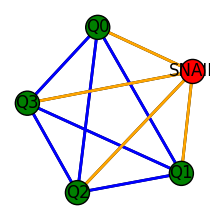

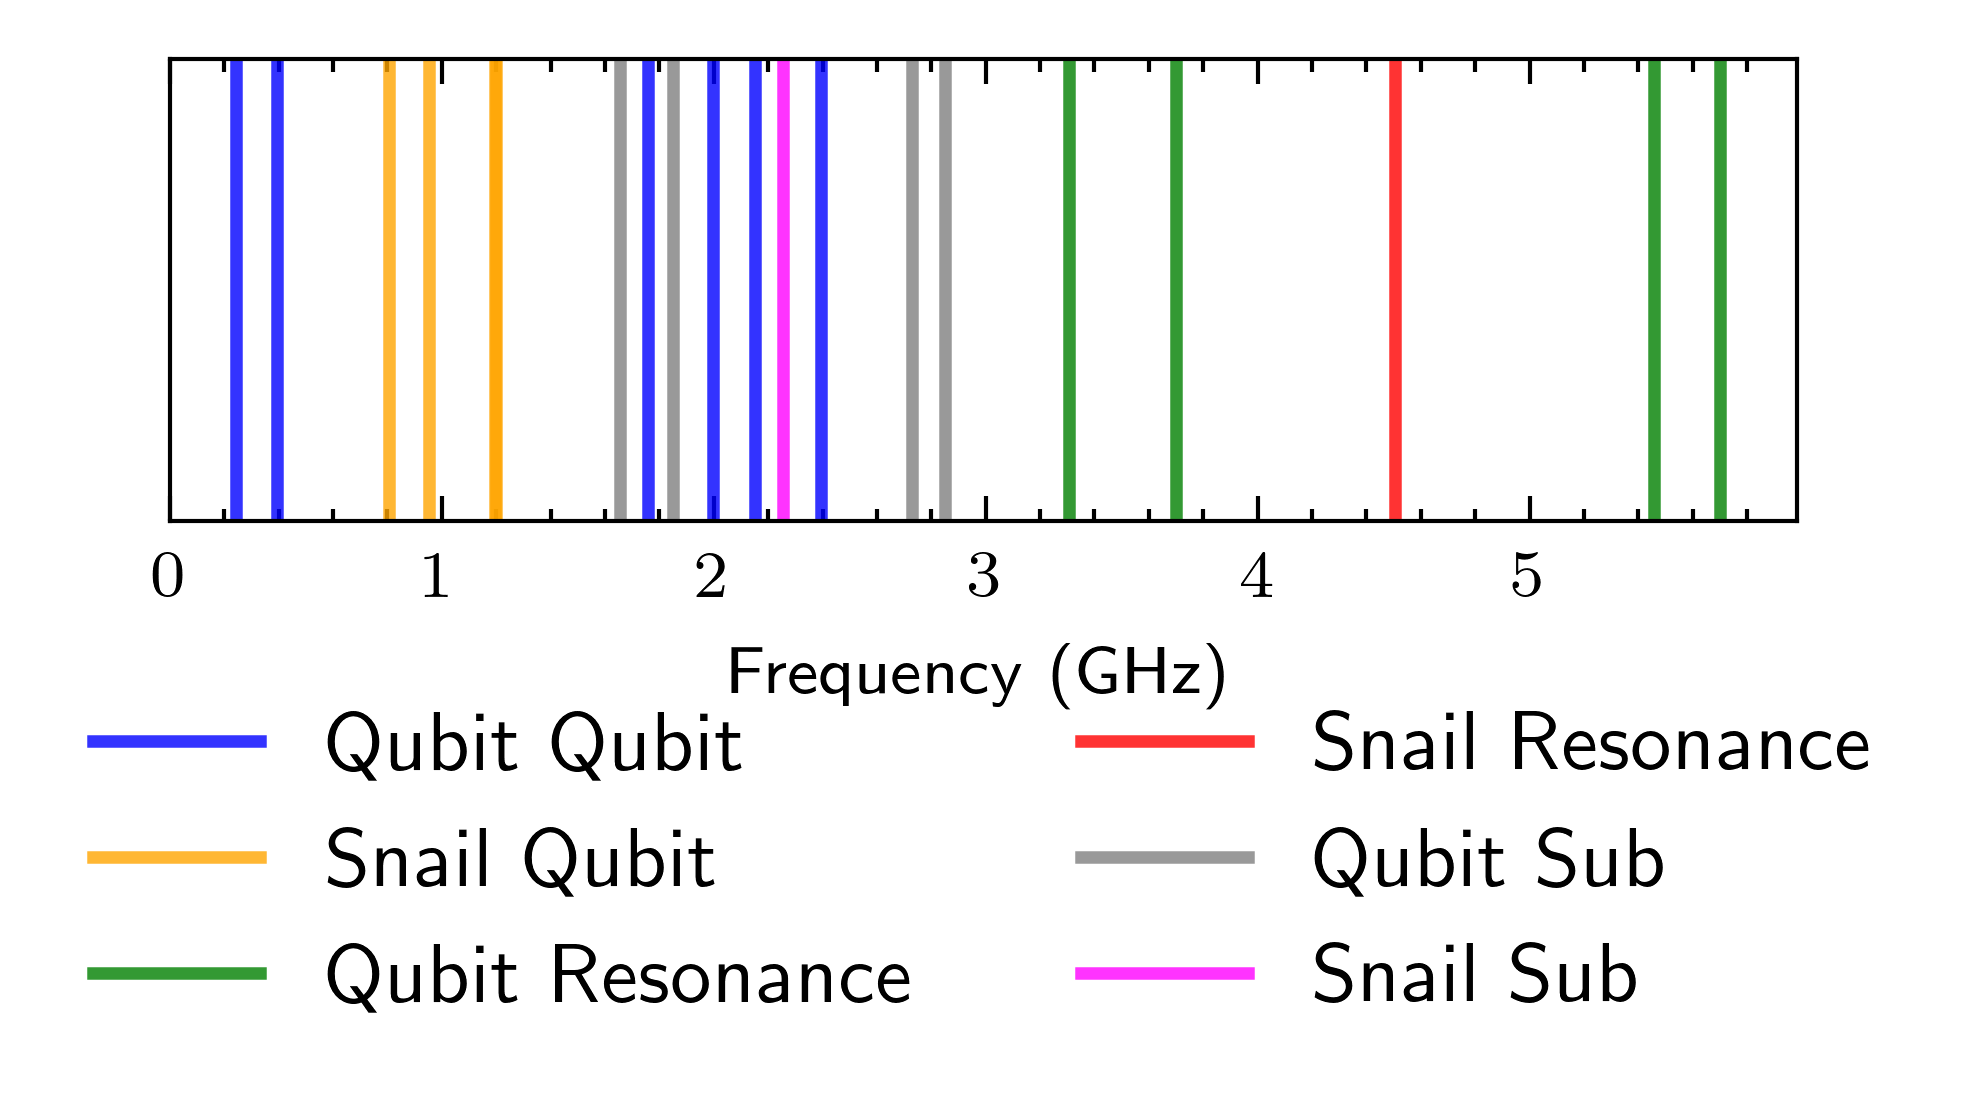

In [7]:
optimizer.report_results()

Remaining standard module sizes:

100%|██████████| 128/128 [00:00<00:00, 130.61it/s]

Optimization terminated successfully.
Qubit Frequencies: [5.7        5.49999935] GHz
SNAIL Frequency: 4.2 GHz
Gate Infidelities:
  Gate ('Q0', 'Q1'): 0.200001 GHz → fidelity (no lifetime loss): 9.988243e-01, fidelity (with lifetime loss): 9.968191e-01

Average Gate fidelity (no lifetime loss): 0.9988242821772718
Average Gate fidelity (with lifetime loss): 0.9968190555446459


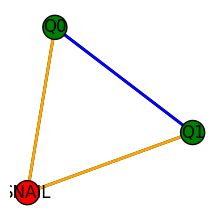

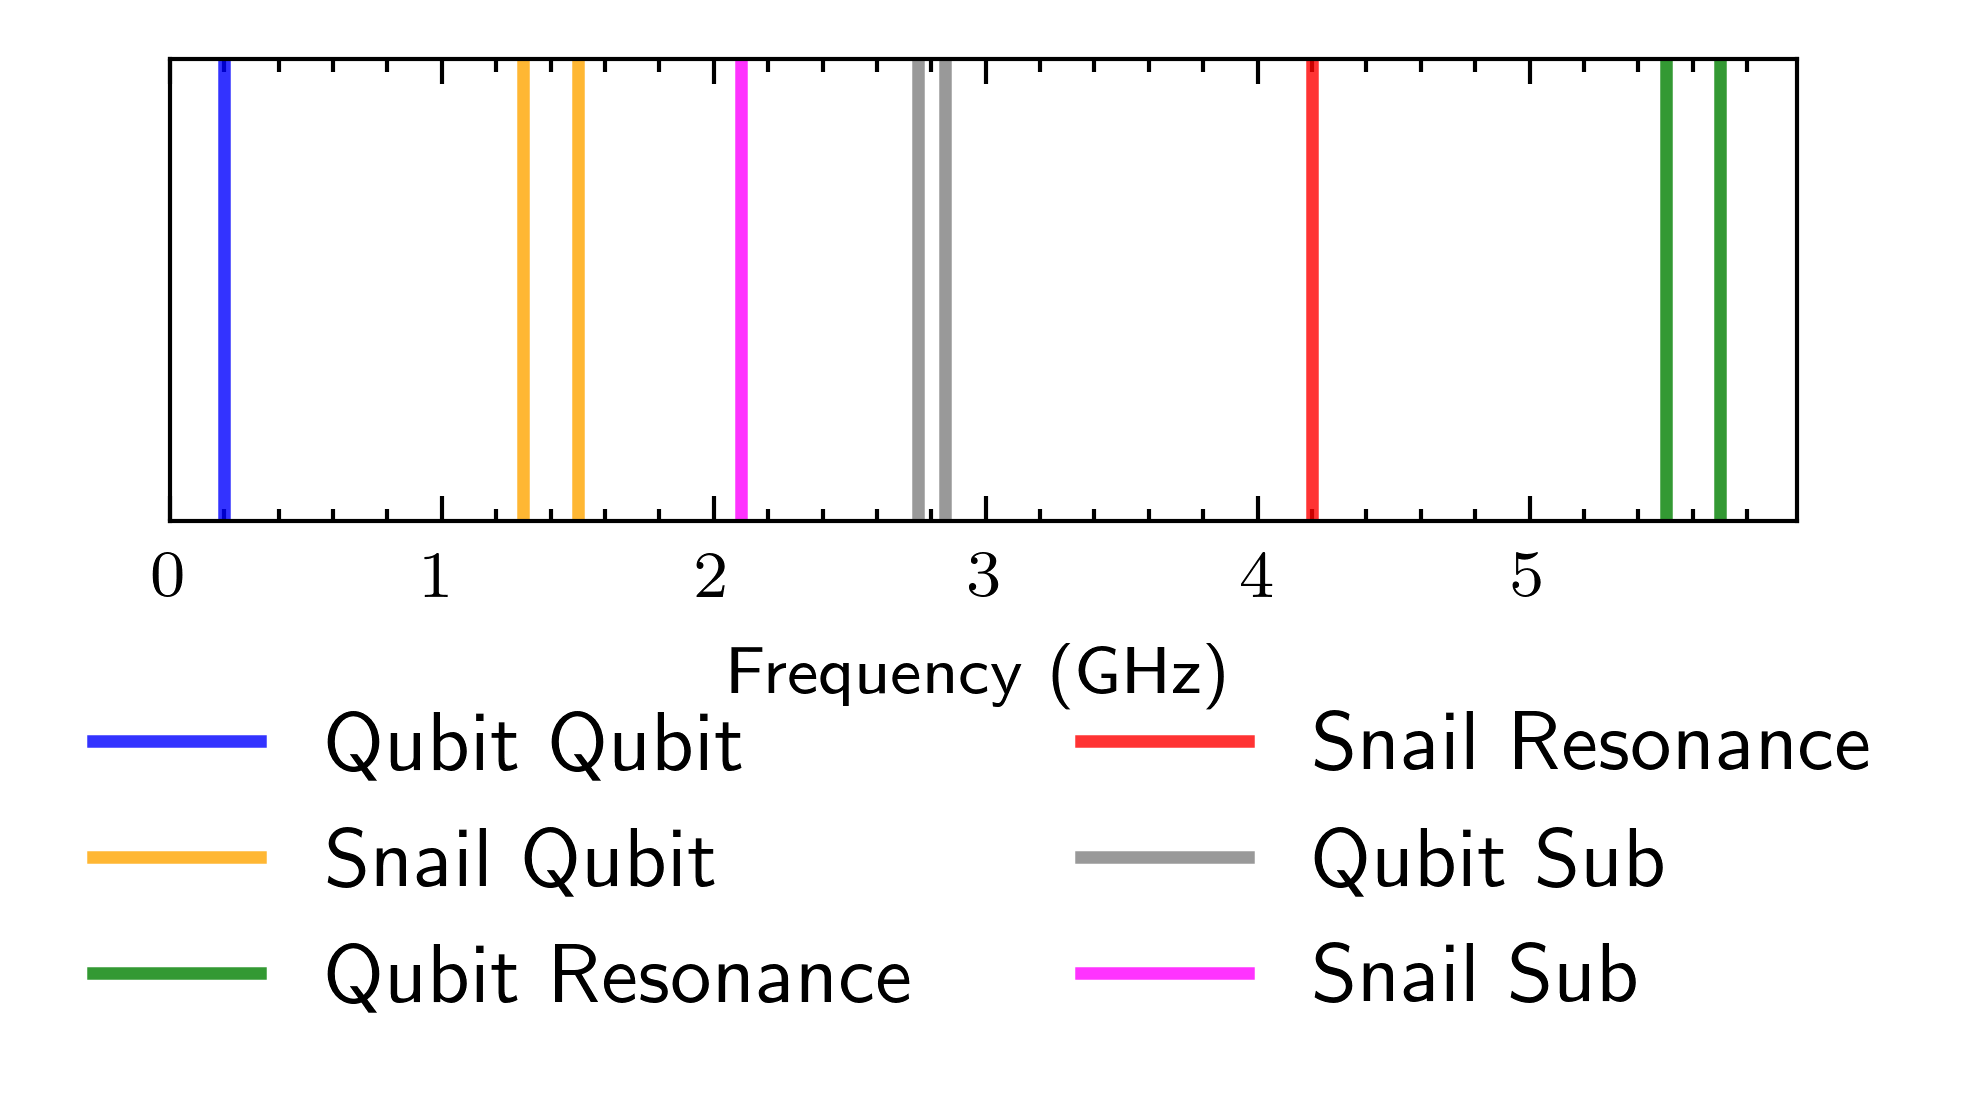

In [11]:
module = QuantumModuleGraph(num_qubits=2)
optimizer = GateFidelityOptimizer(
    module,
    min_bare_space_ghz=0.2,
    lambdaq=0.08,
    eta=1.8,
    g3=60e6,
    T_1=80e-6,
    qubit_bounds=(3.3, 5.7),
    snail_bounds=(4.2, 4.7),
    use_lifetime=True,
)
opt_frequencies, opt_cost = optimizer.optimize_frequencies()
optimizer.report_results()

100%|██████████| 128/128 [00:05<00:00, 25.39it/s]

Optimization terminated successfully.
Qubit Frequencies: [5.4829771  5.15957875 5.6863727 ] GHz
SNAIL Frequency: 4.200000000000036 GHz
Gate Infidelities:
  Gate ('Q0', 'Q1'): 0.323398 GHz → fidelity (no lifetime loss): 9.964677e-01, fidelity (with lifetime loss): 9.950655e-01
  Gate ('Q0', 'Q2'): 0.203396 GHz → fidelity (no lifetime loss): 9.973305e-01, fidelity (with lifetime loss): 9.959934e-01
  Gate ('Q1', 'Q2'): 0.526794 GHz → fidelity (no lifetime loss): 9.934795e-01, fidelity (with lifetime loss): 9.919530e-01

Average Gate fidelity (no lifetime loss): 0.9960530682103146
Average Gate fidelity (with lifetime loss): 0.9945814632934858


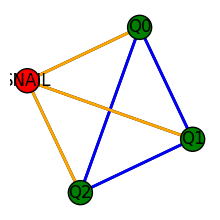

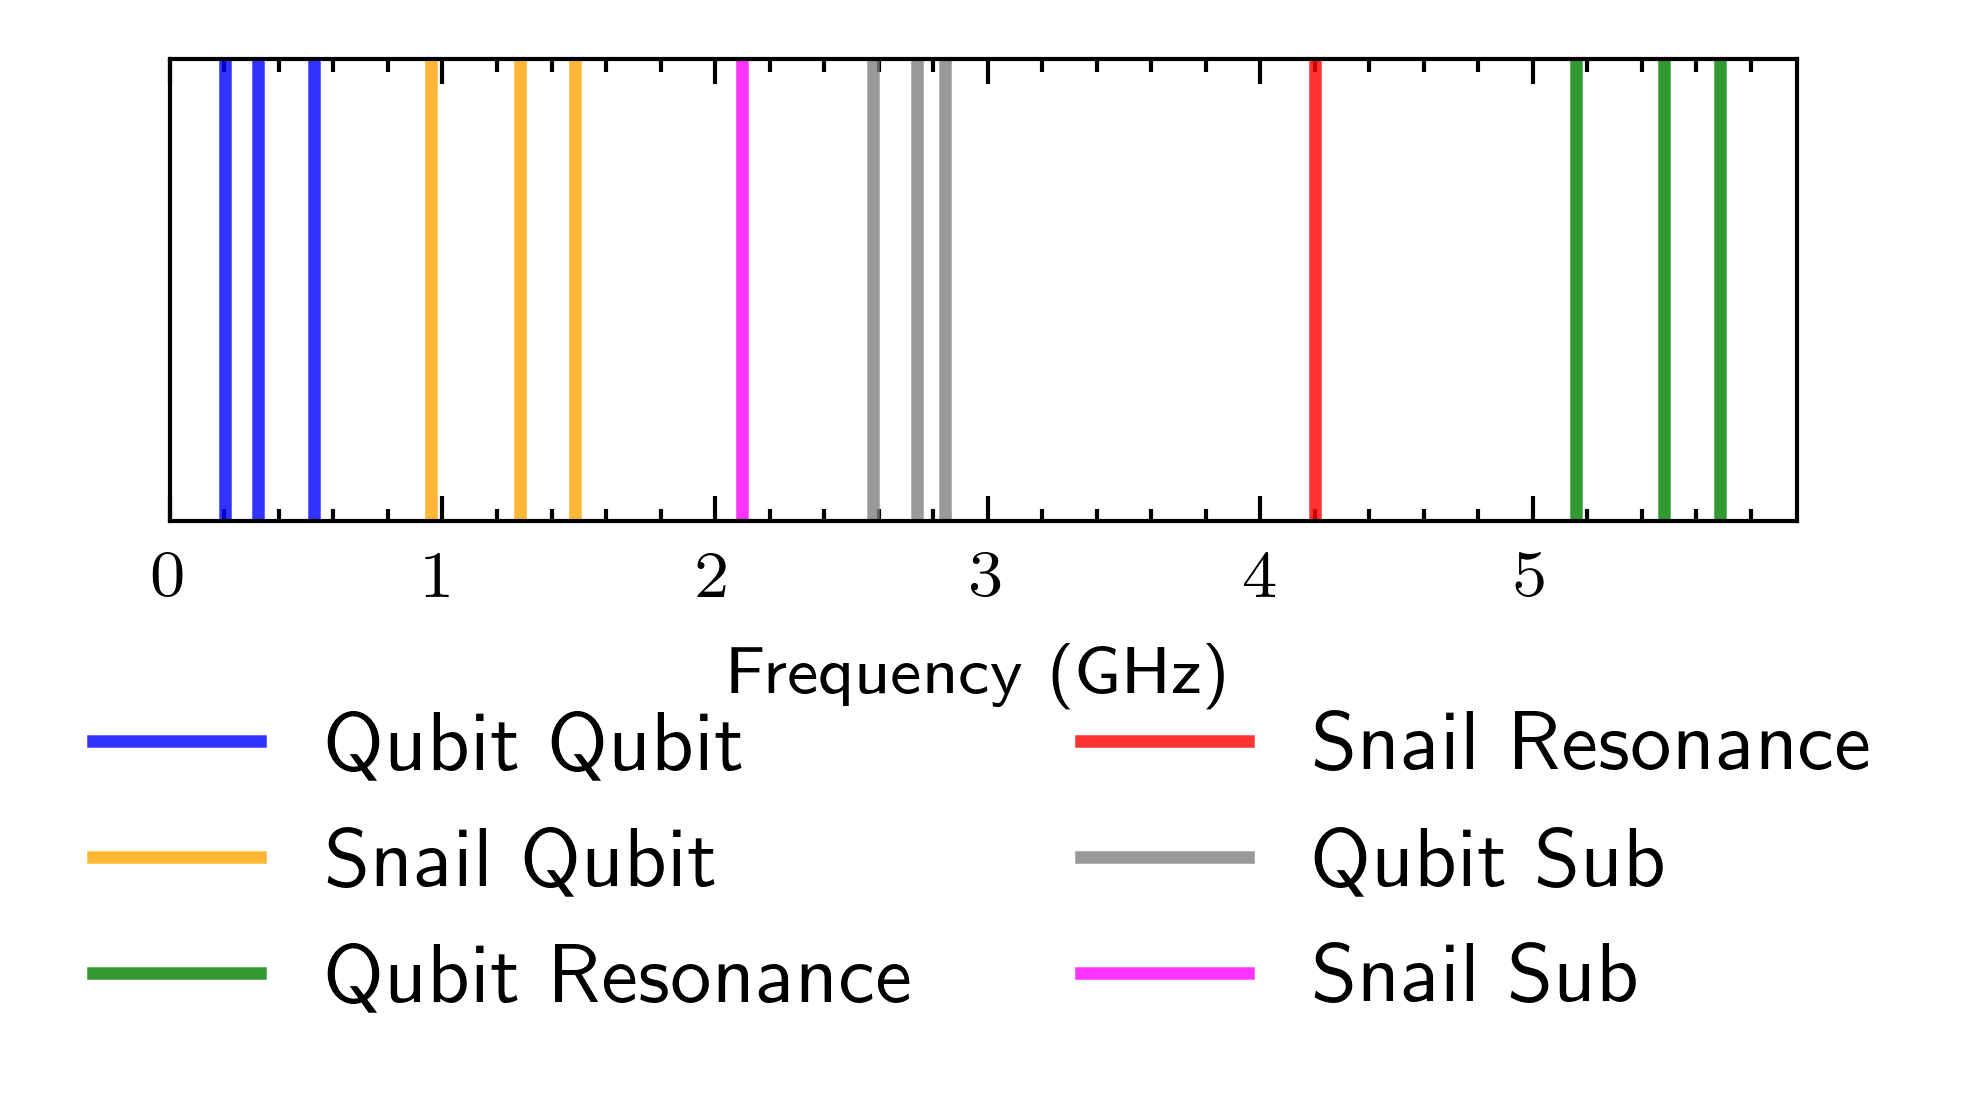

In [12]:
module = QuantumModuleGraph(num_qubits=3)
optimizer = GateFidelityOptimizer(
    module,
    min_bare_space_ghz=0.2,
    lambdaq=0.08,
    eta=1.8,
    g3=60e6,
    qubit_bounds=(3.3, 5.7),
    snail_bounds=(4.2, 4.7),
    use_lifetime=True,
)
opt_frequencies, opt_cost = optimizer.optimize_frequencies()
optimizer.report_results()

100%|██████████| 128/128 [00:38<00:00,  3.37it/s]


Optimization terminated successfully.
Qubit Frequencies: [5.66614065 3.3668845  5.36781469 3.54520923 4.10186131] GHz
SNAIL Frequency: 4.514620264886409 GHz
Gate Infidelities:
  Gate ('Q0', 'Q1'): 2.299256 GHz → fidelity (no lifetime loss): 9.912677e-01, fidelity (with lifetime loss): 9.863257e-01
  Gate ('Q0', 'Q2'): 0.298326 GHz → fidelity (no lifetime loss): 9.371207e-01, fidelity (with lifetime loss): 9.358946e-01
  Gate ('Q0', 'Q3'): 2.120931 GHz → fidelity (no lifetime loss): 9.538821e-01, fidelity (with lifetime loss): 9.497048e-01
  Gate ('Q0', 'Q4'): 1.564279 GHz → fidelity (no lifetime loss): 9.671880e-01, fidelity (with lifetime loss): 9.647209e-01
  Gate ('Q1', 'Q2'): 2.000930 GHz → fidelity (no lifetime loss): 9.134798e-01, fidelity (with lifetime loss): 9.100148e-01
  Gate ('Q1', 'Q3'): 0.178325 GHz → fidelity (no lifetime loss): 9.811309e-01, fidelity (with lifetime loss): 9.799038e-01
  Gate ('Q1', 'Q4'): 0.734977 GHz → fidelity (no lifetime loss): 9.163409e-01, fidelit

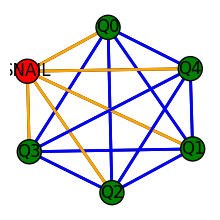

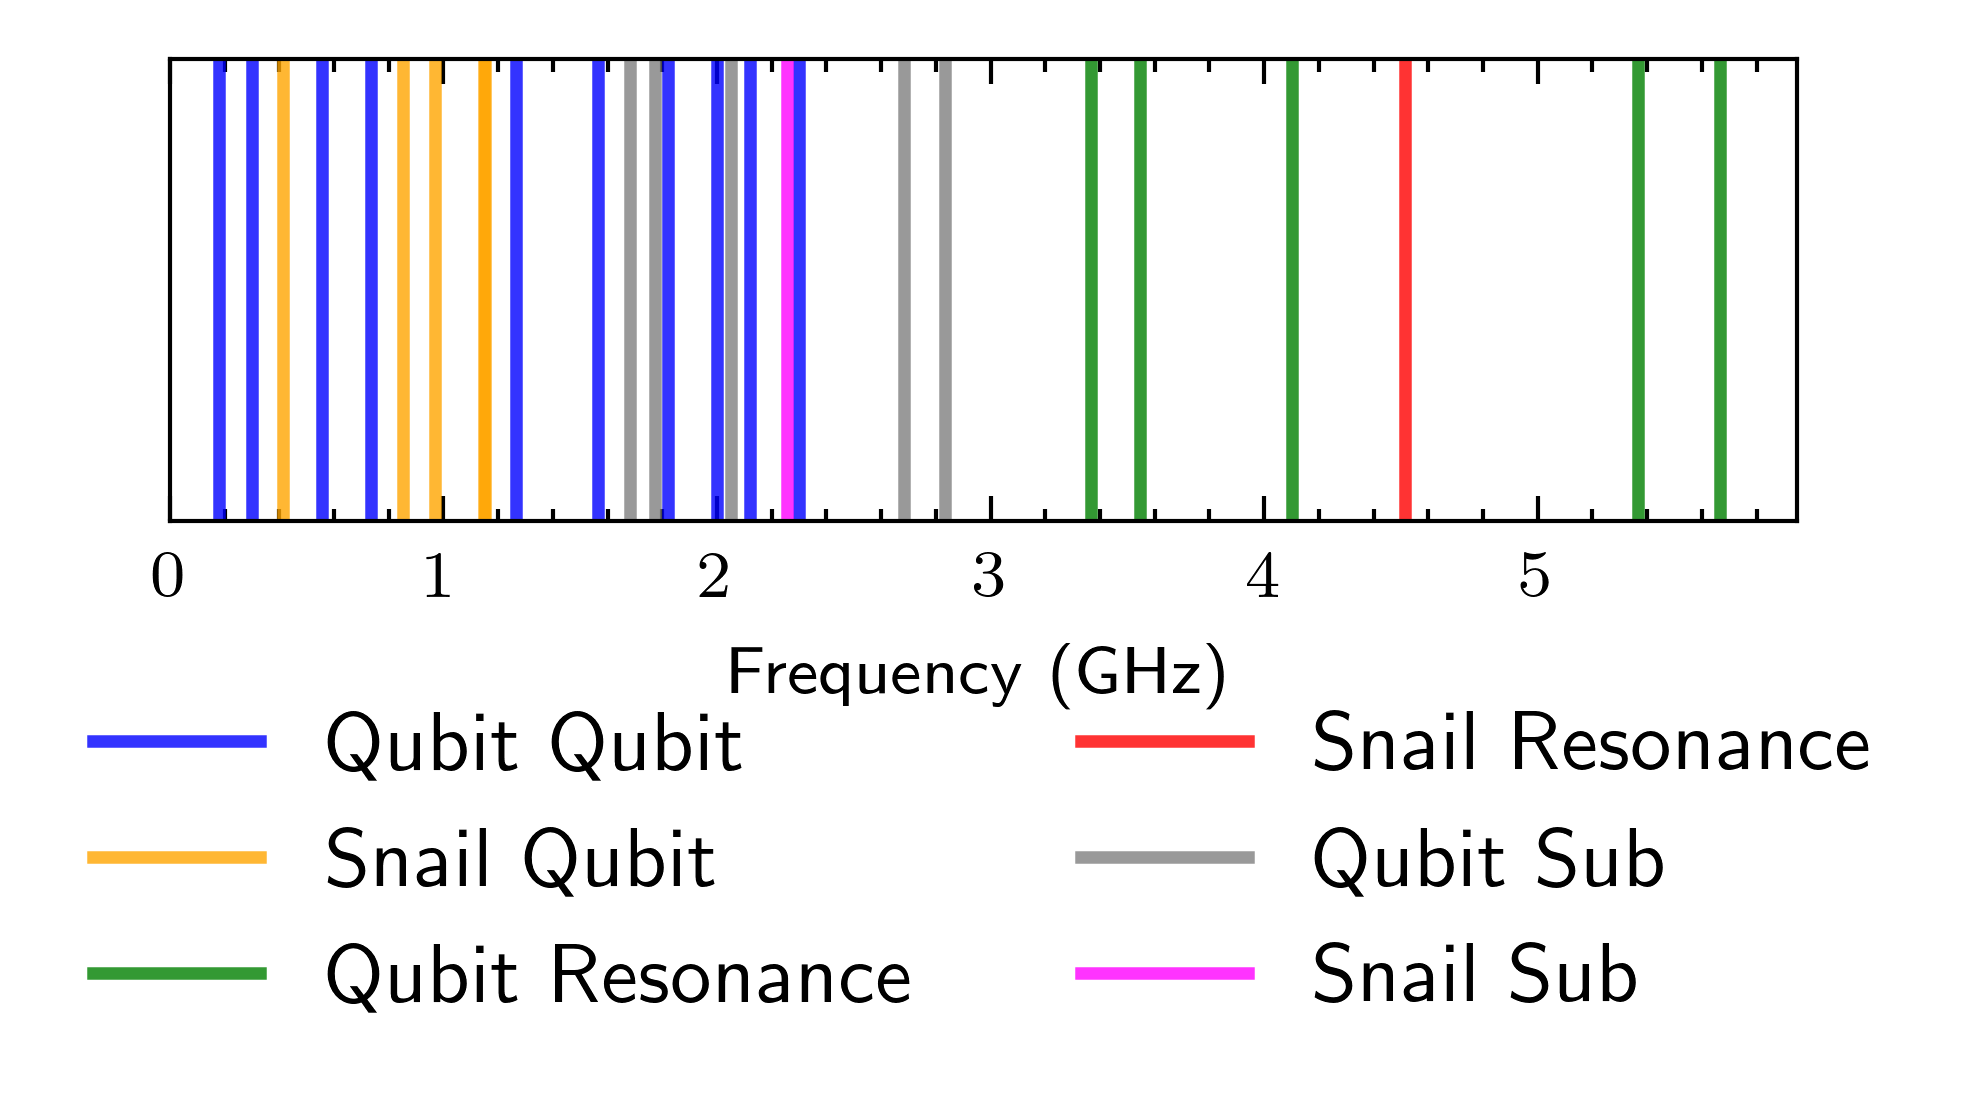

In [13]:
module = QuantumModuleGraph(num_qubits=5)
optimizer = GateFidelityOptimizer(
    module,
    min_bare_space_ghz=0.2,
    lambdaq=0.08,
    eta=1.8,
    g3=60e6,
    qubit_bounds=(3.3, 5.7),
    snail_bounds=(4.2, 4.7),
    drop_k=0,
    use_lifetime=True,
)
opt_frequencies, opt_cost = optimizer.optimize_frequencies()
optimizer.report_results()